# Ports

A **port** marks a connection point on a cell — it records where another cell can
attach to it.  Every port stores:

| Attribute | What it means |
|-----------|---------------|
| `name` | Human-readable identifier (`"o1"`, `"e_in"`, …) |
| `width` | Physical width of the waveguide / wire at this port |
| `layer` | GDS layer the port belongs to |
| `port_type` | `"optical"`, `"electrical"`, or any custom string |
| `trans` / `dcplx_trans` | Position + orientation (one of the two must be set) |

kfactory ships two concrete port classes:

| Class | Coordinate type | When to use |
|-------|----------------|-------------|
| `Port` | DBU integers (nm) | Default — used by `KCell` |
| `DPort` | µm floats | When you prefer floating-point coordinates |

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(11, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(99, 0)


L = LAYER()
kf.kcl.infos = L

## Creating a port

The most explicit way to create a port is to construct it directly.  The orientation
is encoded in a `DCplxTrans` (complex transformation in µm) or a plain `Trans` (DBU).
The angle convention is:

| Angle | Direction |
|-------|-----------|
| `0°`   | East (right) — port faces right, signal exits to the right |
| `90°`  | North (up) |
| `180°` | West (left) |
| `270°` | South (down) |

`DCplxTrans(magnification, angle_deg, mirror, x_um, y_um)`:

In [2]:
port_left = kf.Port(
    name="o1",
    width=kf.kcl.to_dbu(1.0),            # 1 µm → DBU
    dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, -5, 0),  # facing west at (-5, 0) µm
    layer=kf.kcl.find_layer(L.WG),
    kcl=kf.kcl,
)

port_right = kf.Port(
    name="o2",
    width=kf.kcl.to_dbu(1.0),
    dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, 5, 0),     # facing east at (+5, 0) µm
    layer=kf.kcl.find_layer(L.WG),
    kcl=kf.kcl,
)

print(port_left)
print(port_right)

Port(self.name='o1', self.width=1000, trans=r180 *1 -5,0, layer=WG (1/0), port_type=optical)
Port(self.name='o2', self.width=1000, trans=r0 *1 5,0, layer=WG (1/0), port_type=optical)


## Adding ports to a cell

Use `cell.add_port(port=...)` to attach a port to a cell.  `draw_ports()` renders
port markers so you can see direction and position in the notebook.

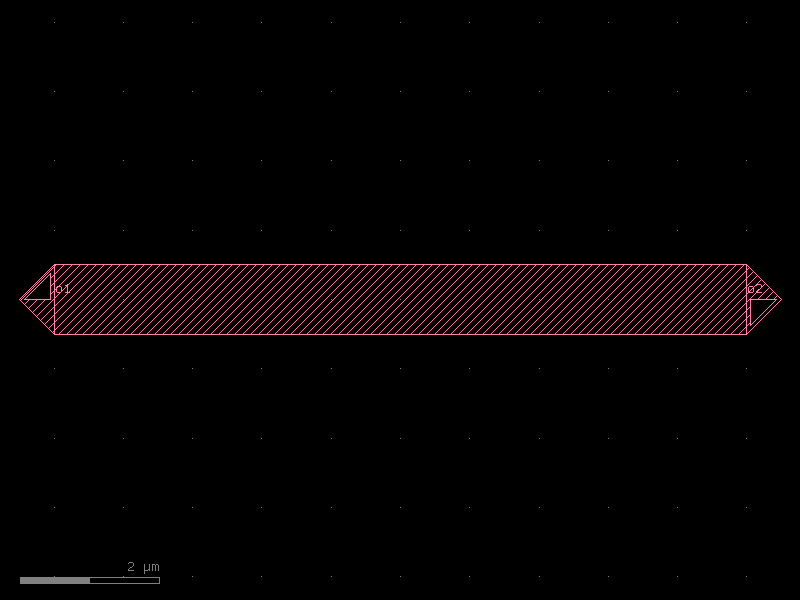

In [3]:
wg = kf.KCell(name="wg_ports_demo")
wg.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(-5, -0.5, 5, 0.5))
wg.add_port(port=port_left)
wg.add_port(port=port_right)

wg.draw_ports()
wg

## Inspecting ports

`cell.ports` returns a `Ports` collection (list-like, with filtering helpers).
Individual ports can be accessed by name using `cell.ports["name"]` or
`cell.port("name")`.

In [4]:
# List all ports
print(wg.ports)

["DPort(self.name='o1', self.width=1.0, trans=r180 *1 -5,0, layer=WG (1/0), port_type=optical)", "DPort(self.name='o2', self.width=1.0, trans=r0 *1 5,0, layer=WG (1/0), port_type=optical)"]


In [5]:
# Access by name
p = wg.ports["o1"]
print(f"name={p.name}  width={p.width} DBU  layer={p.layer_info}  angle={p.angle}°")

name=o1  width=1000 DBU  layer=WG (1/0)  angle=2°


In [6]:
# Inspect position in µm
print(f"x={p.x / wg.kcl.dbu**-1:.3f} µm, y={p.y / wg.kcl.dbu**-1:.3f} µm")
# or use the d-prefix convenience attributes:
print(f"dcplx_trans = {p.dcplx_trans}")

x=-5.000 µm, y=0.000 µm
dcplx_trans = r180 *1 -5,0


## Port types

The `port_type` string distinguishes signal domains.  kfactory uses `"optical"` and
`"electrical"` by convention, but any string is valid.  Routing functions use
`port_type` to avoid accidentally connecting an optical port to an electrical one.

In [7]:
elec_port = kf.Port(
    name="e1",
    width=kf.kcl.to_dbu(2.0),
    dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, -5, 3),
    layer=kf.kcl.find_layer(L.METAL),
    kcl=kf.kcl,
    port_type="electrical",
)
print(f"port_type = {elec_port.port_type}")

port_type = electrical


## Filtering the `Ports` collection

`Ports` exposes several filter helpers — they all return a plain `list[Port]`.

In [8]:
# Build a cell with a mix of optical and electrical ports
mixed = kf.KCell(name="mixed_ports")
mixed.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(-5, -0.5, 5, 0.5))

for name, angle, layer, ptype in [
    ("o1",  180, L.WG,    "optical"),
    ("o2",    0, L.WG,    "optical"),
    ("e1",   90, L.METAL, "electrical"),
    ("e2",  270, L.METAL, "electrical"),
]:
    mixed.add_port(
        port=kf.Port(
            name=name,
            width=kf.kcl.to_dbu(1.0),
            dcplx_trans=kf.kdb.DCplxTrans(1, angle, False, 0, 0),
            layer=kf.kcl.find_layer(layer),
            kcl=kf.kcl,
            port_type=ptype,
        )
    )

In [9]:
# Filter by port_type
optical = mixed.ports.filter(port_type="optical")
print("Optical ports:", [p.name for p in optical])

electrical = mixed.ports.filter(port_type="electrical")
print("Electrical ports:", [p.name for p in electrical])

Optical ports: ['o1', 'o2']
Electrical ports: ['e1', 'e2']


In [10]:
# Filter by angle (facing direction)
west_facing = mixed.ports.filter(angle=180)
print("West-facing ports:", [p.name for p in west_facing])

West-facing ports: []


In [11]:
# Filter by regex on port name
o_ports = mixed.ports.filter(regex="^o")
print("Ports starting with 'o':", [p.name for p in o_ports])

Ports starting with 'o': ['o1', 'o2']


## Bulk port operations: `add_ports` and `copy_ports`

When placing instances inside a parent cell, you often want to expose the child's
ports on the parent.  `add_ports` copies ports from another collection, optionally
adding a prefix to avoid name collisions.

['top_o1', 'top_o2', 'bot_o1', 'bot_o2']


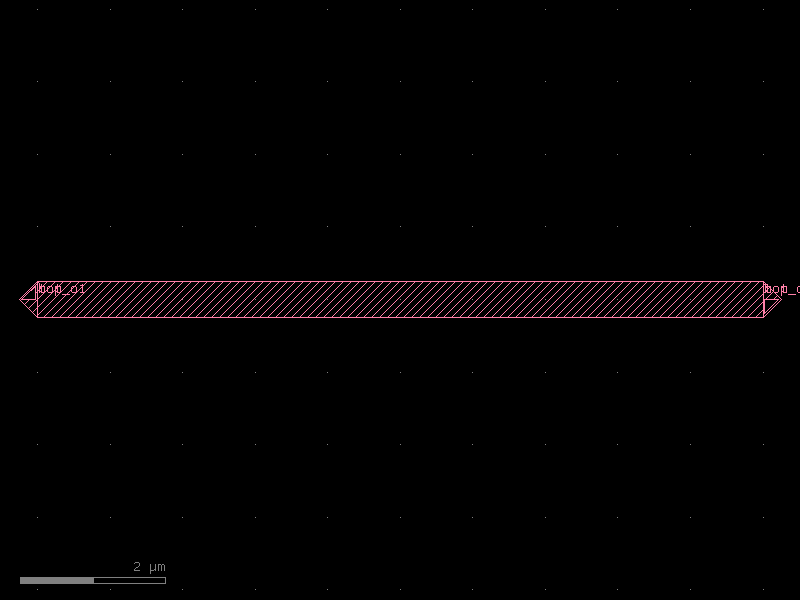

In [12]:
parent = kf.KCell(name="two_wg_parent")

s = kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)
wg1 = parent << s
wg2 = parent << s
wg2.transform(kf.kdb.DTrans(0, 5))   # shift 5 µm north (in DBU: 5000 nm)

parent.add_ports(wg1.ports, prefix="top_")
parent.add_ports(wg2.ports, prefix="bot_")

print([p.name for p in parent.ports])
parent.draw_ports()
parent

## Auto-renaming ports

`auto_rename_ports()` reassigns port names following the gdsfactory convention:
ports are numbered clock-wise starting from the bottom-left west-facing port.
Optical ports get an `o` prefix, electrical ports get `e`.

In [13]:
parent.auto_rename_ports()
print([p.name for p in parent.ports])

['o1', 'o3', 'o2', 'o4']


## Port-based placement with `connect`

`instance.connect("port_name", other_port)` moves and rotates the instance so that
the named port aligns face-to-face with `other_port`.  This is the primary way to
assemble circuits without manually computing positions.

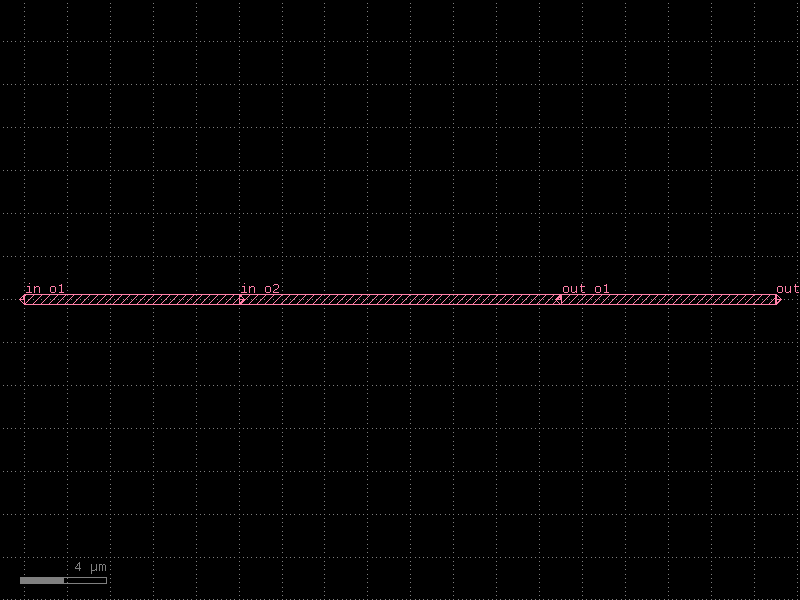

In [14]:
circuit = kf.KCell(name="connected_chain")

seg1 = circuit << kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)
seg2 = circuit << kf.cells.straight.straight(length=15, width=0.5, layer=L.WG)
seg3 = circuit << kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)

# Chain: seg2's o1 aligns with seg1's o2, then seg3's o1 aligns with seg2's o2
seg2.connect("o1", seg1.ports["o2"])
seg3.connect("o1", seg2.ports["o2"])

circuit.add_ports(seg1.ports, prefix="in_")
circuit.add_ports(seg3.ports, prefix="out_")
circuit.draw_ports()
circuit

## Mirrored connections

Ports facing the *same* direction (not opposite) can be connected by specifying
`mirror=True`.  This reflects the instance before alignment — useful for symmetrical
layouts.

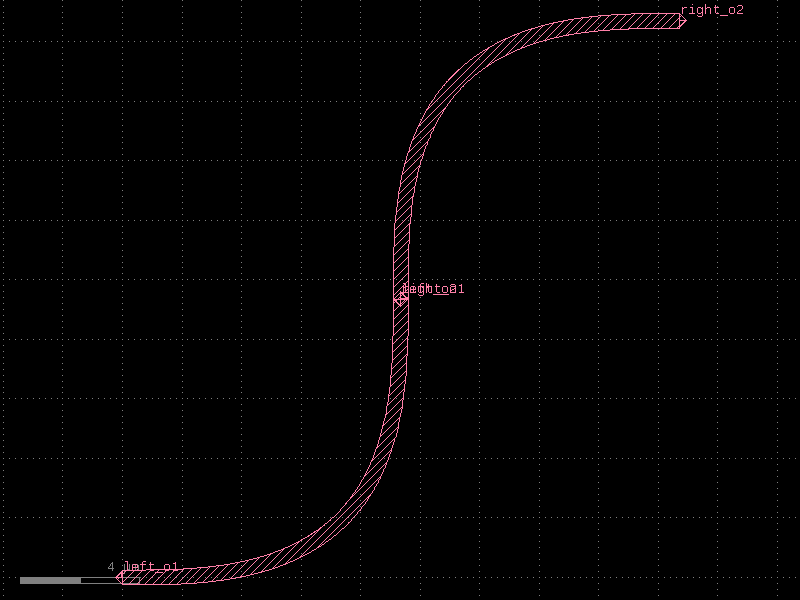

In [15]:
bend = kf.cells.euler.bend_euler(radius=5, width=0.5, layer=L.WG, angle=90)

loop = kf.KCell(name="u_bend")
b1 = loop << bend
b2 = loop << bend
# Mirror b2 so both inputs face the same direction, forming a U-shape
b2.connect("o1", b1.ports["o2"], mirror=True)

loop.add_ports(b1.ports, prefix="left_")
loop.add_ports(b2.ports, prefix="right_")
loop.draw_ports()
loop

## Summary

| Operation | API |
|-----------|-----|
| Create a port | `kf.Port(name=…, width=…, dcplx_trans=…, layer=…, kcl=kf.kcl)` |
| Attach to a cell | `cell.add_port(port=p)` |
| Access by name | `cell.ports["o1"]` |
| Filter by type / angle / regex | `cell.ports.filter(port_type=…, angle=…, regex=…)` |
| Expose child ports on parent | `parent.add_ports(inst.ports, prefix="…")` |
| Auto-rename | `cell.auto_rename_ports()` |
| Connect instance by port | `inst.connect("port_name", other_port)` |
| Visualise | `cell.draw_ports()` |

## See Also

| Topic | Where |
|-------|-------|
| Placing and connecting instances with ports | [Core Concepts: Instances](instances.py) |
| Cross-sections (port width + enclosure spec) | [Cross-Sections](../components/cross_sections.py) |
| Optical routing between ports | [Routing: Overview](../routing/overview.py) |
| Port-based component assembly | [Components: Overview](../components/cells/overview.py) |